Si consideri il data set Titanic composto dai file train.csv e test.csv, allegati al 
presente compito, costituiti da 891+418 record che descrivono i passeggeri del Titanic 
e li etichettano come sopravvissuti o meno sulla base delle seguenti caratteristiche: 
• PassengerId 
• Survived (1/0, solo train) 
• Pclass (1, 2, 3) 
• Name 
• Sex (‘male’, ‘female’) 
• Age (frazionaria se meno di 1; 
se stimata è nella forma xx.5) 
• SibSp  (numero  di  familiari; 
Sibling: fratelli/sorelle; 
Spouse: moglie/marito) 
• Parch  (numero  familiari; 
Parent: padre/madre;  
Child: figli/figlie;  
Parch=0 per piccoli 
accompagnati solo dalla tata) 
• Ticket 
• Fare 
• Cabin 
• Embarked (C = Cherbourg,  
Q = Queenstown,  
S = Southampton)
 
1. Effettuare  uno  split  90%-10%  tra  training  set  e  validation  set.  Individuare 
eventuali dati mancanti e farne l’imputazione secondo criteri che rispecchino 
la  diversa  stratificazione  sociale  e  distribuzione  di  genere  dei  passeggeri 
ovvero  rimuoverle  se  troppo  sparse.  Effettuare  la  codifica  delle  feature 
categoriche e l’eventuale scaling di tutte le feature, una volta trasformate in 
numeriche. Verificare la presenza di feature multicollneari e ridurle tramite 
opportune  combinazioni  lineari.  Infine,  procedere  alla  feature  selection 
attraverso  una  tecnica embedded  che  impieghi  un  classificatore  come 
modello. La scelta del modello embedded è lasciata al candidato, tenendo 
conto che il problema è di classificazione binaria. 
 
punti ___/ 8 
 
2. Implementare un classificatore SVM non lineare per il data set curato risultato 
del punto 1 con i seguenti iper-parametri: 
 
a. C = {1, 1/sqrt(n_samples)} 
b. kernel={RBF, polinomiale} 
c. grado del kernel polinomiale = {3, 4} 
 
Usare l’accuracy come metrica e stampare l’accuracy del miglior classificatore 
e la test accuracy ottenuta in predizione. 
punti ___/ 6 
 
3. Implementare una piccola rete neurale densa con almeno tre layer nascosti 
in  PyTorch,  utilizzando  la  semplice  API  torchnn.py,  per  eseguire  la 
classificazione binaria. Si dovrà implementare anche il relativo Dataset per 
caricare i dati. I layer nascosti dovranno avere un dropout pari a 0.2. Si utilizzi 
per l’addestramento l’ottimizzatore Adam con weight decay pari a 1x10-4 e 
learning rate dercescente esponenzialmente a partire da 0.01. Implementare 
una  callback  di  early  stopping  con  una  pazienza  sulla  validation  loss  di  5 
epoche e un incremento minimo di miglioramento pari a 0.01; implementare 
anche  una  callback  di  model  checkpoint  per  il  salvataggio  del  solo  miglior 
modello rispetto alla minima validation loss. 
punti ___/ 10 
 
4. Conservare la lista delle accuracy di addestramento e di test su tutte le epoche 
del  classificatore  neurale  e  stamparne  il  grafico.  Confrontare  i  risultati  del 
miglior  classificatore  SVM  e  del  classificatore  neurale  calcolando  e 
stampando, per ciascuno, la matrice di confusione, il valore di accuracy e di 
loss.  Calcolare  e  stampare  in  un  unico  grafico  le  curve  ROC  dei  due 
classificatori binari e stamparne anche le relative AUC. 
 
punti ___/ 6 
 
 
TOTALE: punti ___/ 30 
 
 
 
 
 _______________________________________________________________________________________________ 

In [5]:
from sklearn.model_selection import train_test_split
import pandas as pd 

tr = pd.read_csv('../../dbs/train.csv')
te = pd.read_csv('../../dbs/test.csv')

columns_to_drop = ['PassengerId', 'Name','Ticket','Survived','Cabin']

X_tr = tr.drop( columns=columns_to_drop)
y_tr = tr.Survived

X_te = te.drop( columns=columns_to_drop)
y_te = te.Survived

X_tr,X_val, y_tr, y_val = train_test_split(X_tr, y_tr, test_size=0.10, random_state=42, stratify= tr['Survived'])

1. Effettuare  uno  split  90%-10%  tra  training  set  e  validation  set.  Individuare 
eventuali dati mancanti e farne l’imputazione secondo criteri che rispecchino 
la  diversa  stratificazione  sociale  e  distribuzione  di  genere  dei  passeggeri 
ovvero  rimuoverle  se  troppo  sparse.  Effettuare  la  codifica  delle  feature 
categoriche e l’eventuale scaling di tutte le feature, una volta trasformate in 
numeriche. Verificare la presenza di feature multicollneari e ridurle tramite 
opportune  combinazioni  lineari.  Infine,  procedere  alla  feature  selection 
attraverso  una  tecnica embedded  che  impieghi  un  classificatore  come 
modello. La scelta del modello embedded è lasciata al candidato, tenendo 
conto che il problema è di classificazione binaria. 

In [6]:
#print(X_tr.isna().sum())

stratified_medians = X_tr.groupby(['Pclass','Sex'])['Age'].median()


def impute_age_stratified(df, medians):
    df_copy = df.copy()
    for (pclass, sex), median_val in medians.items():
        condition = (
            df_copy["Age"].isna()
            & (df_copy["Pclass"] == pclass)
            & (df_copy["Sex"] == sex)
        )
        df_copy.loc[condition, "Age"] = median_val
    return df_copy


X_tr = impute_age_stratified(X_tr, stratified_medians)
X_val = impute_age_stratified(X_val, stratified_medians)
X_te = impute_age_stratified(X_te, stratified_medians)

mode_embarked = X_tr['Embarked'].mode()[0]

X_tr = X_tr.fillna(mode_embarked)
X_val = X_val.fillna(mode_embarked)
X_te = X_te.fillna(mode_embarked)


print(X_tr.isna().sum())
print(X_te.isna().sum())
print(X_val.isna().sum())


Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [7]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler

encode = OrdinalEncoder().set_output(transform='pandas')
scaler = StandardScaler().set_output(transform='pandas')

num_f = X_tr.select_dtypes( include=('number')).columns.tolist()

cat_f = [ col for col in X_tr.columns if col not in num_f]

cat_f.append('Pclass')
num_f.remove('Pclass')


X_te = X_te.drop(index=152)
y_te = y_te.drop(index=152)



X_tr[cat_f] = encode.fit_transform( X_tr[cat_f] )
X_val[cat_f] = encode.transform( X_val[cat_f] )
X_te[cat_f] = encode.transform( X_te[cat_f] )


X_tr = scaler.fit_transform( X_tr )
X_val = scaler.transform( X_val )
X_te = scaler.transform( X_te )



In [8]:

matrix_corr = X_tr[num_f].corr().abs()

print(matrix_corr) #dalla matrice di correlazione non vedo feature fortemente correlate tra di loro 
print(X_tr.isna().sum())

            Age     SibSp     Parch      Fare
Age    1.000000  0.263123  0.176447  0.129580
SibSp  0.263123  1.000000  0.406509  0.161198
Parch  0.176447  0.406509  1.000000  0.204565
Fare   0.129580  0.161198  0.204565  1.000000
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

classifier = RandomForestClassifier(n_estimators=50)
selector = SelectFromModel(estimator=classifier, threshold='median').set_output(transform='pandas')

print(X_tr.shape)
X_tr_f = selector.fit_transform(X_tr, y_tr)
X_val_f = selector.transform(X_val)
X_te_f = selector.transform(X_te)


print(selector.get_feature_names_out())
print(X_te_f)

(801, 7)
['Pclass' 'Sex' 'Age' 'Fare']
       Pclass       Sex       Age      Fare
0    0.823898  0.735109  0.400896 -0.505715
1    0.823898 -1.360343  1.334305 -0.523118
2   -0.375997  0.735109  2.454397 -0.466712
3    0.823898  0.735109 -0.159150 -0.488225
4    0.823898 -1.360343 -0.532514 -0.412143
..        ...       ...       ...       ...
413  0.823898  0.735109 -0.308495 -0.501080
414 -1.575892 -1.360343  0.736923  1.615576
415  0.823898  0.735109  0.699587 -0.517871
416  0.823898  0.735109 -0.308495 -0.501080
417  0.823898  0.735109 -0.308495 -0.200775

[417 rows x 4 columns]


2. Implementare un classificatore SVM non lineare per il data set curato risultato 
del punto 1 con i seguenti iper-parametri: 
 
a. C = {1, 1/sqrt(n_samples)} 
b. kernel={RBF, polinomiale} 
c. grado del kernel polinomiale = {3, 4} 

In [6]:

from numpy import sqrt
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

param_grid = [
    {
        'C' : [1, 1/sqrt(len(X_tr_f))],
        'kernel': ['rbf']
    },
    {
        
        'C' : [1, 1/sqrt(len(X_tr_f))],
        'kernel': ['poly'],
        'degree': [3,4]
    }
]

search_grid = GridSearchCV(
    estimator= SVC( random_state=42 ),
    param_grid=param_grid,
    scoring= 'accuracy'
)

search_grid.fit(X_tr_f, y_tr)

best_estimator = search_grid.best_estimator_
best_params = search_grid.best_params_

y_pred = search_grid.predict(X_te_f)
acc = accuracy_score( y_te, y_pred)

print( f'accurancy {acc}')

accurancy 0.7793764988009593


In [7]:
import torch
from torch import nn
from torch.utils.data import TensorDataset
import numpy as np

# Importiamo il modulo torchnn fornito dal professore
import torchnn as tnn

# ==========================================
# 1. PREPARAZIONE DEI DATI IN SINTASSI TORCH
# ==========================================
# Supponiamo che tu abbia già diviso le tue feature (X) e target (y) 
# dopo la fase di preprocessing (ad es. X_train, y_train, X_val, y_val, X_test, y_test)

# Convertiamo i vettori NumPy o DataFrame in Tensori PyTorch.
# Le feature X devono essere di tipo float, i target y di tipo long (interi) per CrossEntropyLoss.
X_train_t = torch.tensor(X_tr_f, dtype=torch.float32)
y_train_t = torch.tensor(y_tr, dtype=torch.long)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

X_test_t = torch.tensor(X_te_f, dtype=torch.float32)
y_test_t = torch.tensor(y_te, dtype=torch.long)

# Creiamo i rispettivi oggetti TensorDataset richiesti da PyTorch
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)


# ==========================================
# 2. CREAZIONE DEI DATALOADER (Via torchnn)
# ==========================================
# Selezioniamo il device di calcolo (GPU se disponibile, altrimenti CPU)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo di calcolo selezionato: {device}")

# Generiamo i tre dataloader sfruttando la configurazione predefinita del prof
train_loader, val_loader, test_loader = tnn.make_dataloaders(
    train_data=train_dataset,
    val_data=val_dataset,
    test_data=test_dataset,
    batch=tnn.config["batch_size"] # Valore di default: 64
)


# ==========================================
# 3. DEFINIZIONE DELLA RETE NEURALE (MLP)
# ==========================================
class TitanicClassifier(nn.Module):
    def __init__(self, input_dim, num_classes=2):
        super(TitanicClassifier, self).__init__()
        # Definiamo una struttura Multi-Layer Perceptron standard con Dropout per evitare overfitting
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, num_classes) # 2 output (Logits grezzi)
        )
        
    def forward(self, x):
        # Passo in avanti (Forward pass)
        return self.linear_relu_stack(x)

# Recuperiamo dinamicamente il numero di feature in ingresso
input_features = X_train.shape[1]

# Istanziamo il modello e lo spostiamo sul device corretto
model = TitanicClassifier(input_dim=input_features, num_classes=2).to(device)


# ==========================================
# 4. CONFIGURAZIONE DI OTTIRMIZZATORE E EARLY STOPPING
# ==========================================
# Inizializziamo l'ottimizzatore SGD usando i parametri del dizionario config
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=tnn.config["learning_rate"],   # Default: 1e-3
    momentum=tnn.config["momentum"], # Default: 0.9
    nesterov=tnn.config["nesterov"]  # Default: True
)

# Predisponiamo il meccanismo di Early Stopping
early_stopping = tnn.EarlyStopping(
    patience=tnn.config["patience"],   # Default: 5 epoche
    min_delta=tnn.config["min_delta"]  # Default: 0.01
)


# ==========================================
# 5. CICLO DI ADDESTRAMENTO COMPLETO
# ==========================================
print("\n--- Avvio Addestramento della Rete Neurale ---")

# Lanciamo la funzione train_test di torchnn.
# NOTA: Per eval_loss_fn passiamo nn.CrossEntropyLoss() esplicitamente anziché NLLLoss,
# poiché il nostro modello sputa logit grezzi e non log-probabilities (LogSoftmax).
train_loss, val_loss, test_loss, accuracy, test_metrics = tnn.train_test(
    model=model,
    optimizer=optimizer,
    device=device,
    train_dataloader=train_loader,
    test_dataloader=test_loader,
    epochs=tnn.config["epochs"],             # Default: 20 epoche
    train_loss_fn=tnn.config["train_loss"],  # CrossEntropyLoss
    test_loss_fn=nn.CrossEntropyLoss(),      # Forziamo CrossEntropyLoss anche in validazione
    early_stopping=early_stopping,
    val_dataloader=val_loader
)


# ==========================================
# 6. VISUALIZZAZIONE GRAFICA E SALVATAGGIO
# ==========================================
# Mostriamo i grafici dell'andamento di loss e metriche (Precision, Recall, F1)
tnn.displayLosses(train_loss, test_loss, val_loss)
tnn.displayMetrics(accuracy, test_metrics)

# Salviamo il modello finale in formato pickle (.pth)
checkpoint_name = "titanic_model_checkpoint.pth"
tnn.save_model(
    net=model,
    optimizer=optimizer,
    current_epoch=len(train_loss),
    train_loss=train_loss,
    val_loss=val_loss,
    test_loss=test_loss,
    accuracy=accuracy,
    metrics=test_metrics,
    path=checkpoint_name
)

print(f"\nAddestramento completato! Il checkpoint del modello è stato salvato in '{checkpoint_name}'.")

ValueError: could not determine the shape of object type 'DataFrame'

 
4. .  
stampando, per ciascuno, la matrice di confusione, il valore di accuracy e di 
loss.  Calcolare  e  stampare  in  un  unico  grafico  le  curve  ROC  dei  due 
classificatori binari e stamparne anche le relative AUC. 

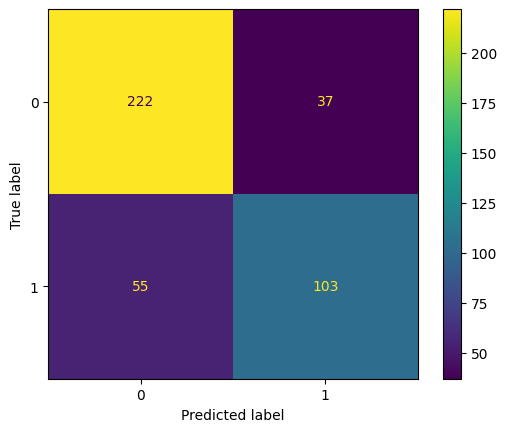

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix


cm = confusion_matrix(y_te, y_pred)
cm_display = ConfusionMatrixDisplay( confusion_matrix= cm )
cm_display.plot()